## **Libraries**

In [88]:
import sys
sys.path.append('../src')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

import visualizations

---
## **Modeling & Evaluation**
### **Data Loading**

- Load data from ``03_feature_engineering`` notebook

In [89]:
path = "../datasets/features.csv"

rfm = pd.read_csv(path, index_col="Customer ID")
display(rfm.head())

,Recency,Frequency,Monetary,NumCancellations,CancelValue,CancelRate,CancelValueRatio,CustomerLifetime,AvgOrderValue,AvgQuantity,PurchaseFrequencyRate,Target
Customer ID,,,,,,,,,,,,
12346,149,12,77556.46,5.0,77608.20,0.384615,1.000654,400,5965.881538,5714.230769,0.029925,0
12347,6,5,2817.48,0.0,0.00,0.000000,0.000000,220,469.580000,303.666667,0.022624,1
12348,72,4,1709.40,0.0,0.00,0.000000,0.000000,189,341.880000,499.400000,0.021053,1
12349,231,3,2671.14,1.0,24.15,0.250000,0.009038,181,667.785000,248.250000,0.016484,1
12350,133,1,334.40,0.0,0.00,0.000000,0.000000,0,167.200000,98.500000,1.000000,0


---
## **Preprocessing**

Before training the model, the following preprocessing steps are applied to the customer-level dataset.


**1. Handle Missing Values**

After feature engineering, some customers may have missing values (e.g., no cancellations).

These are filled with zeros, assuming:
- No cancellations → 0
- No activity → 0


**2. Feature Selection**

We remove:
- Identifiers (e.g., Customer ID)
- Target variable (separated from features)

**3. Encoding**
- Encode categroical variables (Country)

**4. Feature Scaling**

Since features have different ranges:
- Monetary → large values
- Rates → small values

We apply scaling to:
- Improve model performance
- Ensure fair feature contribution


**5. Train-Test Split**

We split the data into:
- Training set → model learns patterns
- Test set → model evaluation

This ensures unbiased performance measurement.

In [90]:
# -------- Encoding --------
#df_model = pd.get_dummies(rfm, columns= ["Country"], drop_first=True)
df_model = rfm.copy()
# -------- Separate target --------
X = df_model.drop(columns=["Target"])
y = df_model["Target"]

# -------- Train-test split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------- Scaling --------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## **Modelling**

In this section, we train multiple classification models to predict whether a customer will purchase again.

We compare:
- Logistic Regression (baseline)
- Random Forest (ensemble)
- XGBoost (boosting)

We use:
- Cross-validation for robust evaluation
- Optuna for hyperparameter tuning
- ROC AUC as the main metric

Finally, we compare models using:
- ROC curves
- Confusion matrices
- Performance metrics (Accuracy, Precision, Recall, F1-score)

### **Logistic Regression**

In [91]:
def objective_logreg(trial):
    C = trial.suggest_loguniform("C", 1e-4, 10)

    model = LogisticRegression(C=C, max_iter=1000)

    score = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_logreg = optuna.create_study(direction="maximize")
study_logreg.optimize(objective_logreg, n_trials=100)

best_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
best_logreg.fit(X_train_scaled, y_train)

[I 2026-03-25 23:46:09,122] A new study created in memory with name: no-name-c7e561de-6b08-4d6d-a6f4-4d12ef14c0a1
C:\Users\HP\AppData\Local\Temp\ipykernel_2560\153898351.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2026-03-25 23:46:09,315] Trial 0 finished with value: 0.8059481965729669 and parameters: {'C': 0.2718103188430922}. Best is trial 0 with value: 0.8059481965729669.
C:\Users\HP\AppData\Local\Temp\ipykernel_2560\153898351.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2026-03-25 23:46:09,529] Trial 1 finished with value: 0.8062217705663294 and parameters: {

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.799677805485302
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

### **SVM**

In [92]:
def objective_svm(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 100, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
    }

    model = SVC(
        **params,
        probability=True  # needed for ROC AUC
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=30)

best_svm = SVC(
    **study_svm.best_params,
    probability=True
)

best_svm.fit(X_train_scaled, y_train)

[I 2026-03-25 23:46:28,976] A new study created in memory with name: no-name-44ea0ab8-55ca-4427-abcb-5ca4e5caa538
[I 2026-03-25 23:46:32,852] Trial 0 finished with value: 0.797451307110658 and parameters: {'C': 0.06595270590503517, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.797451307110658.
[I 2026-03-25 23:46:36,823] Trial 1 finished with value: 0.7955434856354147 and parameters: {'C': 7.009406606406798, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.797451307110658.
[I 2026-03-25 23:46:38,889] Trial 2 finished with value: 0.8016983490058674 and parameters: {'C': 0.007158497057916208, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 2 with value: 0.8016983490058674.
[I 2026-03-25 23:46:42,806] Trial 3 finished with value: 0.7967700186825502 and parameters: {'C': 0.24935989376503004, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.8016983490058674.
[I 2026-03-25 23:46:49,135] Trial 4 finished with value: 0.7820769952389016

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.164649972194774
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### **KNN**

In [93]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 30),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)  # 1=Manhattan, 2=Euclidean
    }

    model = KNeighborsClassifier(**params)

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_knn = optuna.create_study(direction="maximize")
study_knn.optimize(objective_knn, n_trials=30)

best_knn = KNeighborsClassifier(**study_knn.best_params)
best_knn.fit(X_train_scaled, y_train)

[I 2026-03-25 23:49:11,689] A new study created in memory with name: no-name-3109567d-fae4-4ae3-a1f4-12cb51b0f556
[I 2026-03-25 23:49:12,061] Trial 0 finished with value: 0.7984396915397027 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7984396915397027.
[I 2026-03-25 23:49:12,221] Trial 1 finished with value: 0.8062378636512015 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'p': 1}. Best is trial 1 with value: 0.8062378636512015.
[I 2026-03-25 23:49:12,402] Trial 2 finished with value: 0.7932244005789121 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.8062378636512015.
[I 2026-03-25 23:49:12,489] Trial 3 finished with value: 0.7456907471897636 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 0.8062378636512015.
[I 2026-03-25 23:49:12,577] Trial 4 finished with value: 0.7464716094158101 and parameters: {'n_neighbors': 3, 'weights': 

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",29
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### **Naive Bayes**

In [94]:
def objective_nb(trial):
    var_smoothing = trial.suggest_float("var_smoothing", 1e-12, 1e-6, log=True)

    model = GaussianNB(var_smoothing=var_smoothing)

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_nb = optuna.create_study(direction="maximize")
study_nb.optimize(objective_nb, n_trials=30)

best_nb = GaussianNB(**study_nb.best_params)
best_nb.fit(X_train_scaled, y_train)

[I 2026-03-25 23:49:15,316] A new study created in memory with name: no-name-d1241ade-53c7-49c2-9bd1-774ffd0c5828
[I 2026-03-25 23:49:15,360] Trial 0 finished with value: 0.7847075320034386 and parameters: {'var_smoothing': 4.177796998820495e-09}. Best is trial 0 with value: 0.7847075320034386.
[I 2026-03-25 23:49:15,400] Trial 1 finished with value: 0.7847075320034386 and parameters: {'var_smoothing': 7.631237174842078e-11}. Best is trial 0 with value: 0.7847075320034386.
[I 2026-03-25 23:49:15,441] Trial 2 finished with value: 0.7847075320034386 and parameters: {'var_smoothing': 3.3277869917815584e-07}. Best is trial 0 with value: 0.7847075320034386.
[I 2026-03-25 23:49:15,482] Trial 3 finished with value: 0.7847075320034386 and parameters: {'var_smoothing': 1.729190382699503e-07}. Best is trial 0 with value: 0.7847075320034386.
[I 2026-03-25 23:49:15,524] Trial 4 finished with value: 0.7847075320034386 and parameters: {'var_smoothing': 3.2475361903996995e-08}. Best is trial 0 with v

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",4.177796998820495e-09


### **Random Forest** 

In [95]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }

    model = RandomForestClassifier(**params, random_state=42)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
best_rf.fit(X_train, y_train)

[I 2026-03-25 23:49:16,596] A new study created in memory with name: no-name-70d9072e-cf4c-4e07-8178-9938d3f1a26b
[I 2026-03-25 23:49:33,388] Trial 0 finished with value: 0.817189174405865 and parameters: {'n_estimators': 434, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 0 with value: 0.817189174405865.
[I 2026-03-25 23:49:56,387] Trial 1 finished with value: 0.8130200084696627 and parameters: {'n_estimators': 431, 'max_depth': 12, 'min_samples_split': 7}. Best is trial 0 with value: 0.817189174405865.
[I 2026-03-25 23:50:23,524] Trial 2 finished with value: 0.8123457821304367 and parameters: {'n_estimators': 495, 'max_depth': 13, 'min_samples_split': 6}. Best is trial 0 with value: 0.817189174405865.
[I 2026-03-25 23:50:40,924] Trial 3 finished with value: 0.816567609890509 and parameters: {'n_estimators': 386, 'max_depth': 8, 'min_samples_split': 3}. Best is trial 0 with value: 0.817189174405865.
[I 2026-03-25 23:51:00,610] Trial 4 finished with value: 0.8137696277800028 an

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",453
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### **XGBoost**

In [96]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params, random_state=42)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric="logloss", random_state=42)
best_xgb.fit(X_train, y_train)

[I 2026-03-25 23:56:41,100] A new study created in memory with name: no-name-f4ea1bde-6790-49e3-8081-2e7849f7d7eb
[I 2026-03-25 23:56:44,716] Trial 0 finished with value: 0.7791735304780867 and parameters: {'n_estimators': 323, 'max_depth': 10, 'learning_rate': 0.2608399567470705, 'subsample': 0.6290876357493655, 'colsample_bytree': 0.7509717117948478}. Best is trial 0 with value: 0.7791735304780867.
[I 2026-03-25 23:56:47,031] Trial 1 finished with value: 0.7789151000010642 and parameters: {'n_estimators': 330, 'max_depth': 6, 'learning_rate': 0.26565505260685873, 'subsample': 0.7230768664815905, 'colsample_bytree': 0.7469864502574174}. Best is trial 0 with value: 0.7791735304780867.
[I 2026-03-25 23:56:48,705] Trial 2 finished with value: 0.8048171435855934 and parameters: {'n_estimators': 183, 'max_depth': 7, 'learning_rate': 0.05850019916087555, 'subsample': 0.9339451737660853, 'colsample_bytree': 0.7599390789946476}. Best is trial 2 with value: 0.8048171435855934.
[I 2026-03-25 23

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8413072186070142
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

## **Evaluation**

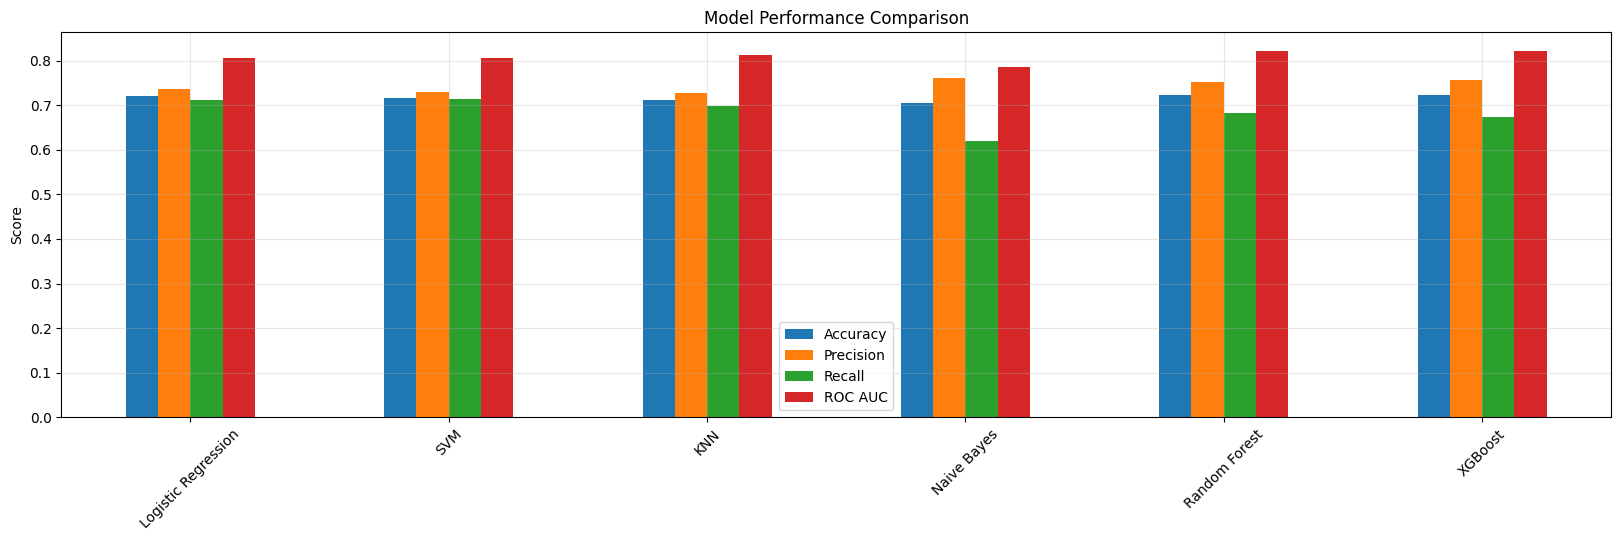

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.720721,0.735887,0.711501,0.723489,0.806818
SVM,0.716717,0.729084,0.713450,0.721182,0.806001
KNN,0.710711,0.727642,0.697856,0.712438,0.812246
Naive Bayes,0.704705,0.760766,0.619883,0.683136,0.784877
Random Forest,0.721722,0.752688,0.682261,0.715746,0.820672
XGBoost,0.721722,0.757112,0.674464,0.713402,0.822261


In [97]:
models = {
    "Logistic Regression": best_logreg,
    "SVM": best_svm,
    "KNN": best_knn,
    "Naive Bayes": best_nb,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = {}
roc_data = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    # Select correct dataset
    if name in ["Random Forest", "XGBoost"]:
        X_train_used = X_train
        X_test_used = X_test
    else:
        X_train_used = X_train_scaled
        X_test_used = X_test_scaled

    # -------- CV ROC AUC (aligned with Optuna) --------
    cv_scores = cross_val_score(
        model,
        X_train_used,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # -------- Fit on full training --------
    model.fit(X_train_used, y_train)

    # -------- Test evaluation --------
    y_pred = model.predict(X_test_used)
    y_proba = model.predict_proba(X_test_used)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": cv_scores.mean(),
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)


results_df = pd.DataFrame(results).T
results_df[["Accuracy", "Precision", "Recall", "ROC AUC"]].plot(kind="bar", figsize=(20,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

results_df

### **ROC-AUC**

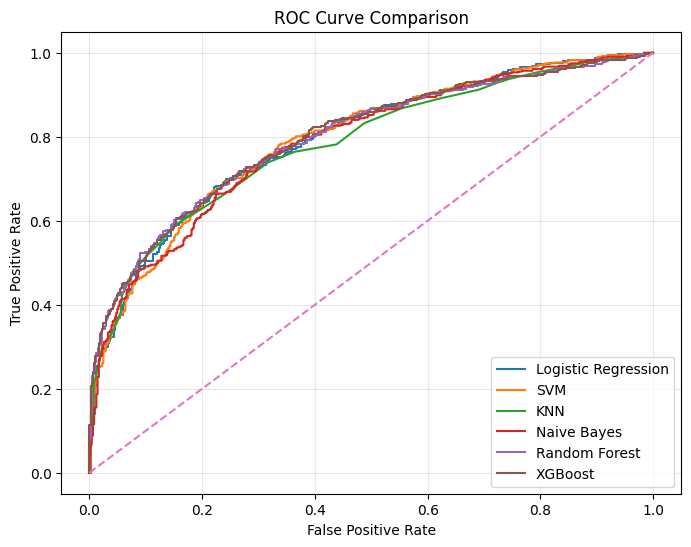

In [98]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The evaluated models (Logistic Regression, SVM, KNN, Naive Bayes, Random Forest, and XGBoost) show **very similar performance across all metrics**. Accuracy, Precision, Recall, F1-score, and ROC AUC are all within a relatively narrow range, indicating that:

- The problem is **well-defined and stable**
- The engineered features (especially RFM-based) are strong and informative
- More complex models do not drastically outperform simpler ones


Although performance is similar, some models stand out depending on the metric:

- **Random Forest and XGBoost**
  - Best **ROC AUC (~0.80)** → strongest ability to rank customers by likelihood of returning
  - Good balance across all metrics
  - More robust for decision-making

- **KNN**
  - Highest **F1-score (~0.685)** → best balance between Precision and Recall
  - Slightly better at overall classification trade-off

- **Logistic Regression / SVM**
  - Very stable and consistent
  - Slightly lower performance but highly interpretable

- **Naive Bayes**
  - Lower **Recall (~0.55)** → misses many returning customers
  - Less suitable for this use case


**Business-Oriented Interpretation**

The dataset is **moderately imbalanced**:
- Class 0 (non-repeat): 3010  
- Class 1 (repeat): 2284  

The objective is:

- **Loyalty actions** → identify customers likely to return (class 1)
- **Retention actions** → identify customers at risk (class 0)


**Metric Importance**

- **ROC AUC (most important)**  
  - Measures ranking ability → crucial for targeting campaigns  
  - Best models: Random Forest, XGBoost  

- **Recall (important for loyalty actions)**  
  - Higher recall = more returning customers correctly identified  
  - Best: Logistic Regression / SVM / KNN  

- **Precision (important for retention cost efficiency)**  
  - Higher precision = fewer wasted resources  
  - Best: Random Forest  

- **F1-score (balance)**  
  - Best overall: KNN  


- All models perform similarly because the **signal in the data is strong and consistent**
- **Random Forest and XGBoost are slightly better overall**, especially for ranking customers (ROC AUC)
- **KNN offers the best balance**, but may not scale well
- **Naive Bayes underperforms**, especially in identifying returning customers


For this project:

- Use **Random Forest or XGBoost** for production (best overall performance and ranking ability)
- Use **probabilities (not hard predictions)** to:
  - Target high-probability customers → loyalty actions  
  - Target low-probability customers → retention actions  

This approach aligns best with business objectives and maximizes marketing effectiveness.

### **Feature Importance**

**Feature Importance for Non-Tree Models**

Not all models provide native feature importance:

- Tree-based models (Random Forest, XGBoost) compute importance based on splits
- Logistic Regression and linear SVM use coefficients

However:
- KNN is distance-based and does not learn explicit feature weights
- Naive Bayes is probabilistic and assumes feature independence

To address this, we use **permutation importance**, which measures how model performance decreases when a feature is randomly shuffled.

This method:
- Works for any model
- Provides a consistent way to compare importance across models


- SVM importance is only available for linear kernels
- Permutation importance is more computationally expensive
- Results may vary slightly due to randomness


Permutation importance allows us to extend feature importance analysis to all models, enabling a fair comparison across different modeling approaches.

In [99]:
feature_names = X.columns

if best_svm.kernel == "linear":
    svm_importance = pd.Series(
        best_svm.coef_[0],
        index=feature_names
    )
else:
    svm_importance = pd.Series(0, index=X.columns)


knn_perm = permutation_importance(
    best_knn,
    X_test_scaled,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
knn_importance = pd.Series(knn_perm.importances_mean, index=X.columns)

nb_perm = permutation_importance(
    best_nb,
    X_test_scaled,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
nb_importance = pd.Series(nb_perm.importances_mean, index=X.columns)

logreg_importance = pd.Series(
    best_logreg.coef_[0],
    index=feature_names
).sort_values()

rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values()

xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values()

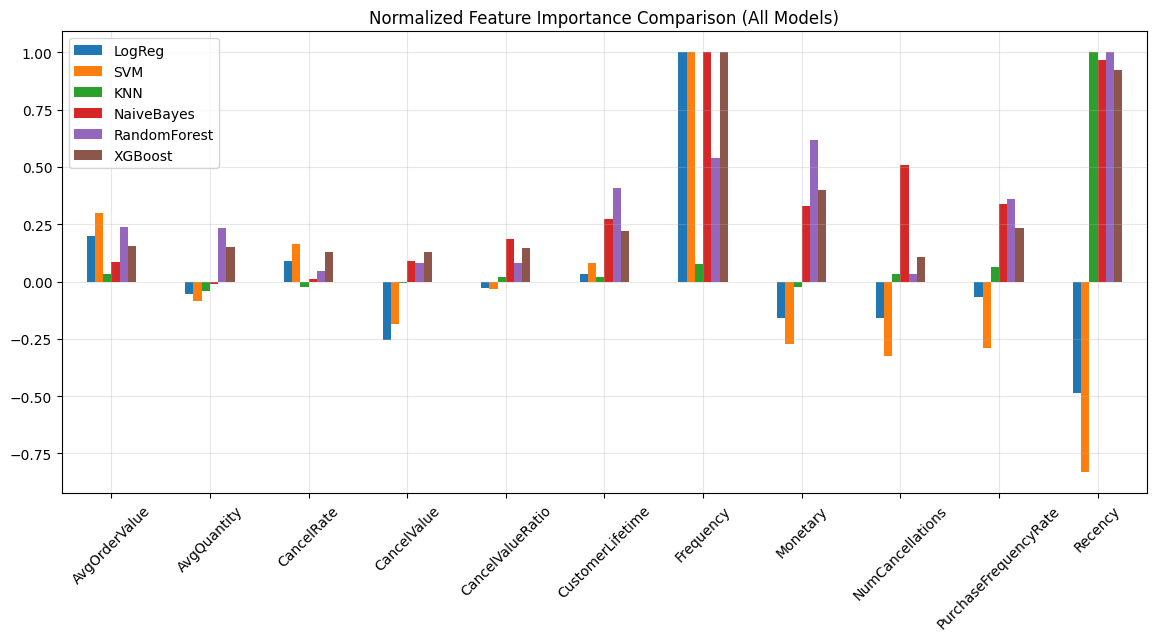

In [102]:
importance_df = pd.DataFrame({
    "LogReg": logreg_importance,
    "SVM": svm_importance,
    "KNN": knn_importance,
    "NaiveBayes": nb_importance,
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance
})

# Normalize
importance_df_norm = importance_df / importance_df.max()

importance_df_norm.plot(kind="bar", figsize=(14,6))

plt.title("Normalized Feature Importance Comparison (All Models)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

The models show a **high level of agreement** on the most important features:

- **Recency, Frequency, and Monetary (RFM)** consistently appear as the most influential variables  
- Secondary features such as **CustomerLifetime and cancellation-related variables** also contribute, but with less importance  

This agreement indicates that:
- The models are capturing the **same underlying customer behavior patterns**
- The feature engineering is robust and meaningful  

This is expected becasue:

When different models: Identify the **same key features** and Extract similar patterns from the data, their performance tends to converge.  

This explains why all models achieved **similar metrics**:  
they are essentially learning the same relationships between customer behavior and repeat purchases.


**Why do Logistic Regression and SVM have negative values?**

- Logistic Regression and linear SVM provide **coefficients**, not importance scores  
- A **positive value** means:
  - The feature increases the probability of being a repeat customer  

- A **negative value** means:
  - The feature decreases that probability  

For example:
- **Recency (negative)** → the longer since last purchase, the lower the chance of returning  
- **Frequency (positive)** → more frequent buyers are more likely to return  

The sign gives **direction**, not just importance  


Why we normalize the variable importance values?

Each model calculates importance differently:
- Tree models → split-based importance  
- Linear models → coefficients  
- Permutation → performance impact  

To compare them, we normalize:

\[
\text{Normalized Importance} = \frac{\text{feature importance}}{\max(\text{importance})}
\]

This means:
- Values are scaled between **-1 and 1 (or 0 and 1 depending on model)**
- The **most important feature = 1**
- Others are expressed **relative to it**

This allows a **fair comparison across models**


These results match the expected results for an RFM problem, since in a RFM-based problem:

- **Recency** is usually the strongest predictor  
- **Frequency** indicates loyalty  
- **Monetary** reflects customer value  

The results confirm:
- Customers who buy **recently and frequently** are more likely to return  
- Cancellation behavior slightly reduces this probability  

---
## **Business Actions Based on Results**

### Loyalty Actions (High Probability Customers)

These customers:
- Purchased recently  
- Buy frequently  
- Have higher monetary value  

Recommended actions:
- Personalized promotions  
- Loyalty programs or rewards  
- Early access to products  
- Upselling and cross-selling  

Goal: **maximize value from already loyal customers**



### Retention Actions (Low Probability Customers)

These customers:
- Have high Recency (inactive for a long time)  
- Lower Frequency  
- Possibly higher cancellation behavior  

Recommended actions:
- Re-engagement campaigns (emails, discounts)  
- Special offers or incentives  
- Reminders or product recommendations  

Goal: **reactivate customers before they churn**


## Final Conclusion

- Models agree on the importance of RFM features  
- Similar feature importance explains similar model performance  
- Results align with expected behavior in customer analytics  

The model provides a strong foundation to:
- Identify valuable customers  
- Optimize marketing strategies  
- Improve customer retention and lifetime value